In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey
from pathlib import Path
from scipy.signal import welch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

## Funzione finestra: DA SISTEMARE

In [94]:
def window_organ_signal(signal, sample_rate, return_info=False):

    """
    Individua automaticamente il tratto utile del segnale, lo ritaglia e applica
    una finestra di Tukey per evitare click e leakage.

    signal: Array numpy del segnale audio.
    sample_rate: Frequenza di campionamento.
    return_info: Se True, restituisce anche indici e parametri del taglio.
    return: Segnale ritagliato e finestrato.
    """

    signal = np.asarray(signal)
    if signal.size == 0:
        if return_info:
            return signal, 0, 0, 0.0
        return signal

    envelope = np.abs(signal)
    smooth_len = max(3, int(0.01 * sample_rate))
    smooth_kernel = np.ones(smooth_len) / smooth_len
    smoothed = np.convolve(envelope, smooth_kernel, mode='same')

    # 1. Prima lettura: trova la parte attiva del segnale.
    peak_level = np.max(smoothed)
    noise_floor = np.percentile(smoothed, 20)
    base_threshold = max(noise_floor * 1.15, peak_level * 0.08)
    threshold = min(base_threshold, peak_level * 0.6)
    active_samples = np.flatnonzero(smoothed >= threshold)

    start_sample = 0
    end_sample = len(signal)

    if active_samples.size > 0:
        # Scarta sempre almeno il primo secondo e cerca il tratto piu stabile dopo.
        minimum_start = min(len(signal), int(1.0 * sample_rate))
        stable_window = max(int(0.06 * sample_rate), 128)
        end_guard = max(int(0.08 * sample_rate), stable_window)

        search_start = max(active_samples[0], minimum_start)
        max_center_start = int(0.65 * len(signal))
        search_stop = min(
            active_samples[-1] + 1,
            len(smoothed) - stable_window - end_guard,
            max_center_start,
        )

        best_start = search_start
        best_score = np.inf

        if search_stop > search_start:
            search_span = max(1, search_stop - search_start)
            for idx in range(search_start, search_stop):
                segment = smoothed[idx:idx + stable_window]
                if segment.size < stable_window:
                    break

                segment_mean = np.mean(segment)
                if segment_mean < threshold:
                    continue

                segment_std = np.std(segment)
                base_score = segment_std / (segment_mean + 1e-12)

                # Penalita lieve per partenze troppo tarde.
                late_penalty = 0.12 * ((idx - search_start) / search_span)
                score = base_score + late_penalty

                if score < best_score:
                    best_score = score
                    best_start = idx

        start_sample = max(best_start, minimum_start)
        padding_end = max(int(0.05 * sample_rate), int(0.01 * len(signal)))
        end_sample = min(len(signal), len(signal) - padding_end)

    if end_sample <= start_sample:
        trimmed_signal = signal[start_sample:]
    else:
        trimmed_signal = signal[start_sample:end_sample]

    if len(trimmed_signal) == 0:
        if return_info:
            return trimmed_signal, start_sample, end_sample, 0.0
        return trimmed_signal

    # 2. Sceglie automaticamente la larghezza del fade in base alla durata del taglio.
    fade_samples = max(1, int(0.02 * sample_rate))
    fade_fraction = min(0.2, max(0.02, (2 * fade_samples) / len(trimmed_signal)))
    win = tukey(len(trimmed_signal), alpha=fade_fraction)

    # 3. Applica la finestra e restituisce direttamente il segnale ritagliato.
    windowed_signal = trimmed_signal * win
    if return_info:
        return windowed_signal, start_sample, end_sample, fade_fraction
    return windowed_signal

## Funzione analisi di una nota

In [95]:
"""Il Problema: La FFT \"Grezza\" (Periodogramma)
Se prendi un segnale intero (come hai fatto all'inizio del tuo notebook) e gli applichi una singola, gigantesca Trasformata di Fourier (FFT), ottieni un risultato molto instabile. Se c'è anche un minimo rumore di fondo, il grafico esploderà in una miriade di picchi \"seghettati\" e frastagliati. Questo fenomeno si chiama alta varianza: il risultato varia tantissimo a causa del rumore casuale, nascondendo le vere frequenze del segnale.

La Soluzione: Il Metodo di Welch
Il metodo di Welch risolve questo problema usando la statistica, in particolare la forza della media matematica. Lo fa in 4 passaggi fondamentali:

1.⁠ ⁠Segmentazione (Divisione in blocchi)
Invece di fare una singola FFT lunga quanto tutto il file audio, Welch prende il segnale e lo \"affetta\" in tanti blocchi più corti. La lunghezza di questi blocchi è il famoso parametro nperseg (Number of Points PER SEGment).

2.⁠ ⁠Sovrapposizione (Overlap)
Se tagliassimo il segnale come se fossero mattoni, perderemmo delle informazioni proprio nei punti di taglio. Per evitare questo, i segmenti vengono fatti sovrapporre (di solito del 50%). Quindi il primo segmento va da 0 a 1000, il secondo va da 500 a 1500, il terzo da 1000 a 2000, e così via.

3.⁠ ⁠Finestratura (Windowing)
A ciascuno di questi segmenti viene applicata una \"finestra\" matematica (spesso chiamata finestra di Hann o Hamming). Questa curva smussa i bordi di ogni singolo segmento portandoli dolcemente a zero. Questo previene un brutto difetto matematico chiamato Spectral Leakage (dispersione spettrale), che altrimenti creerebbe frequenze fantasma che non esistono davvero.

4.⁠ ⁠FFT e Media
A questo punto, il metodo calcola la potenza della FFT per ogni singolo segmento. Se hai diviso il file in 100 pezzetti, avrai 100 grafici FFT separati. Infine, fa la media di tutti questi 100 grafici.

Il risultato e il \"Compromesso di Welch\"
Facendo la media, il rumore casuale di fondo si annulla a vicenda (perché a volte va su, a volte va giù), mentre le frequenze stabili (come la nota del tuo organo) si sommano e si confermano. Il risultato è quel grafico bellissimo e smussato che hai ottenuto.

C'è però un compromesso fondamentale (Trade-off) che devi decidere quando scegli il parametro nperseg:

nperseg PICCOLO (es. 256): Avrai tantissimi segmenti di cui fare la media. Il grafico sarà incredibilmente liscio e senza rumore, ma i picchi saranno molto larghi e \"cicciotti\" (poca risoluzione in frequenza). Farai fatica a distinguere due frequenze molto vicine.

nperseg GRANDE (es. 4096 o 8192): Avrai pochi segmenti di cui fare la media. I picchi saranno sottilissimi e precisi (altissima risoluzione in frequenza), ma la linea di base tornerà ad essere un po' frastagliata e rumorosa."""

def analizza_nota_welch_mono(file_path, nperseg=8192):
    """
    Converte in mono, ritaglia e calcola lo spettro mediato.
    """
    # 1. Caricamento e Normalizzazione
    samplerate, data = wavfile.read(file_path)
    if data.dtype == np.int16:
        data = data / 32768.0

    # 2. Conversione in MONO (Media dei canali)
    if len(data.shape) > 1:
        signal_mono = np.mean(data, axis=1)
    else:
        signal_mono = data

    # 3. Ritaglio e Windowing (Sostegno)
    # Ora la funzione decide da sola quanto ritagliare e quanto sfumare i bordi.
    signal_cut = window_organ_signal(signal_mono, samplerate)

    # 4. Calcolo PSD con Welch
    # Ho alzato nperseg a 8192 per darti più risoluzione sulle note basse
    freqs, psd = welch(signal_cut, fs=samplerate, nperseg=nperseg)

    # 5. Plotting (Singolo grafico, molto più chiaro)
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, 10 * np.log10(psd + 1e-12), color='forestgreen')
    plt.title(f"Spettro di Potenza (Mono) - {Path(file_path).name}")
    plt.xlabel('Frequenza (Hz)')
    plt.ylabel('Potenza (dB/Hz)')
    plt.xlim(0, 5000)
    
    # Griglia più fitta in x: major ogni 100 Hz, minor ogni 20 Hz
    ax = plt.gca()
    ax.set_xticks(np.arange(0, 5001, 300))
    #ax.set_xticks(np.arange(0, 5001, 20), minor=True)
    ax.grid(True, which='major', alpha=0.35)
    #ax.grid(True, which='minor', axis='x', alpha=0.2, linestyle=':')

    plt.tight_layout()
    plt.show()
    
    return freqs, psd

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_57814/2854580780.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(sample_file)


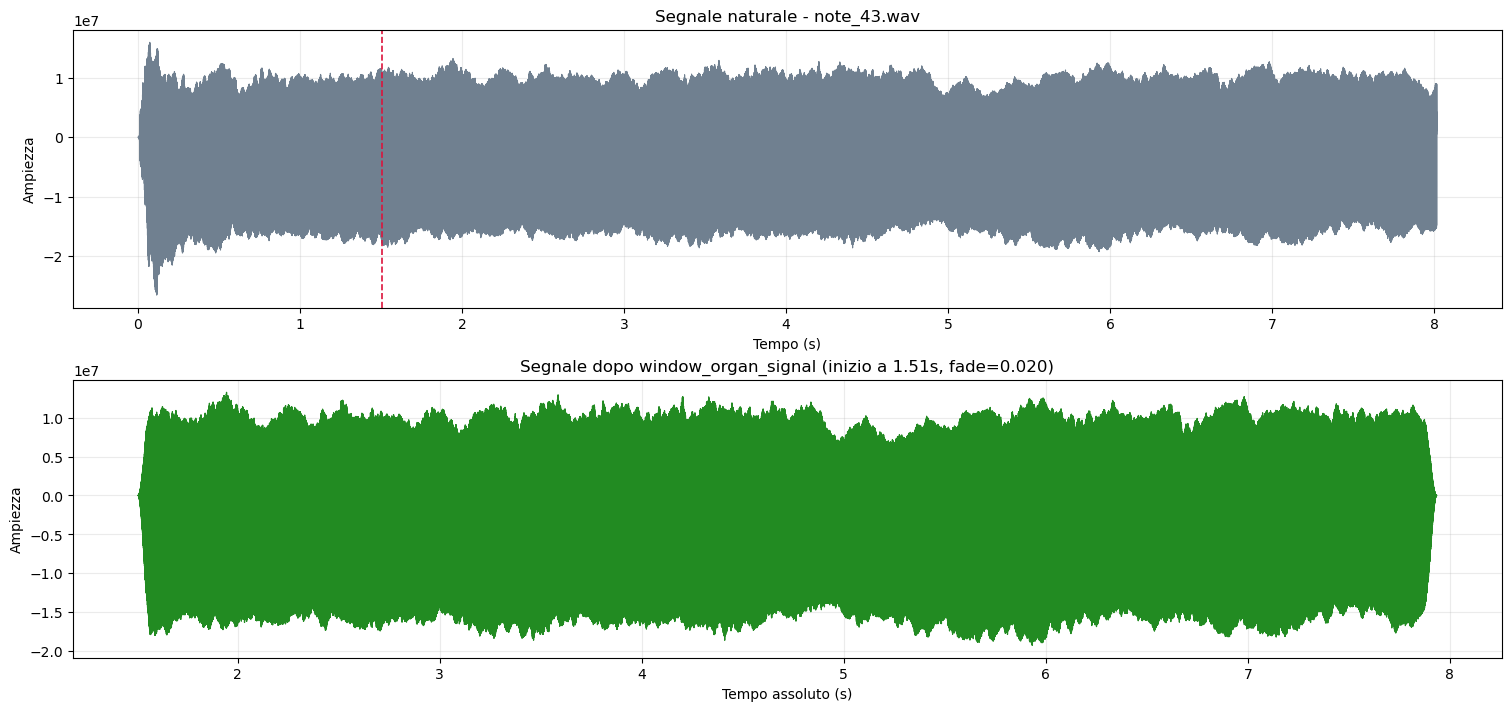

In [96]:
# Esempio visivo: confronto tra segnale naturale e segnale ritagliato/finestrato
sample_file = Path('data/note_43.wav')

samplerate, data = wavfile.read(sample_file)
if data.dtype == np.int16:
    data = data / 32768.0

if len(data.shape) > 1:
    signal_mono = np.mean(data, axis=1)
else:
    signal_mono = data

windowed_signal, start_idx, end_idx, fade_fraction = window_organ_signal(
    signal_mono, samplerate, return_info=True
)

raw_time = np.arange(len(signal_mono)) / samplerate
windowed_time = (start_idx + np.arange(len(windowed_signal))) / samplerate

fig, axes = plt.subplots(2, 1, figsize=(15, 7), constrained_layout=True)

axes[0].plot(raw_time, signal_mono, color='slategray', linewidth=0.8)
axes[0].axvline(start_idx / samplerate, color='crimson', linestyle='--', linewidth=1.2)
axes[0].set_title(f'Segnale naturale - {sample_file.name}')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Ampiezza')
axes[0].grid(True, alpha=0.25)

axes[1].plot(windowed_time, windowed_signal, color='forestgreen', linewidth=0.9)
axes[1].set_title(
    f'Segnale dopo window_organ_signal (inizio a {start_idx / samplerate:.2f}s, fade={fade_fraction:.3f})'
)
axes[1].set_xlabel('Tempo assoluto (s)')
axes[1].set_ylabel('Ampiezza')
axes[1].grid(True, alpha=0.25)

plt.show()

## Trova la frequanza fondamentale anche se manca con MCD

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_57814/2021017566.py:33: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


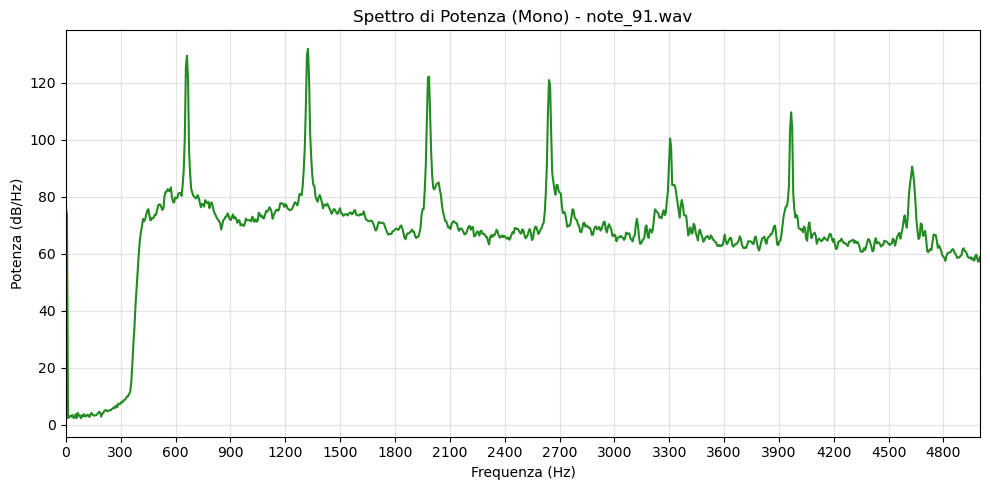

La frequenza fondamentale stimata è: 662.11 Hz


In [97]:
def mcd_euclide_float(a, b, tolleranza=2.0):
    """
    Versione dell'algoritmo di Euclide per numeri float.
    Si ferma quando il resto è inferiore alla tolleranza.
    """
    while b > tolleranza:
        a, b = b, a % b
    return a

def identifica_f0_euclide(freqs, psd, num_picchi=5):
    """
    Identifica la fondamentale calcolando il Massimo Comun Divisore 
    tra le frequenze dei picchi principali usando il metodo di Euclide.
    """
    # 1. Trova i picchi principali (semplice ricerca locale)
    soglia = np.max(psd) * 0.1
    picchi_idx = []
    for i in range(1, len(psd) - 1):
        if psd[i] > psd[i-1] and psd[i] > psd[i+1] and psd[i] > soglia:
            picchi_idx.append(i)
    
    f_picchi = freqs[picchi_idx[:num_picchi]]
    
    if len(f_picchi) < 2:
        return f_picchi[0] if len(f_picchi) == 1 else 0

    # 2. Applichiamo Euclide in cascata sui picchi trovati
    # Calcoliamo l'MCD tra il primo e il secondo, poi il risultato col terzo, ecc.
    # Usiamo una tolleranza legata alla risoluzione della FFT (es. 2-5 Hz)
    res_mcd = f_picchi[0]
    for i in range(1, len(f_picchi)):
        res_mcd = mcd_euclide_float(res_mcd, f_picchi[i], tolleranza=2.5)
    
    # 3. Controllo di plausibilità
    # A volte l'MCD può risultare in una sottarmonica (es. f0/2). 
    # Se il valore è troppo basso (es. < 15Hz per un organo), potrebbe esserci un errore.
    
    return res_mcd


freqs, psd = analizza_nota_welch_mono('data/note_91.wav')
f0 = identifica_f0_euclide(freqs, psd)
print(f"La frequenza fondamentale stimata è: {f0:.2f} Hz")

## Analisi di tutte le note: DOVREMMO USARE WELCH COME PRIMA?

In [ ]:
def process_organ_notes(folder_path):
    
    data_dir = Path(folder_path)
    files = sorted(data_dir.glob('note_*.wav'))
    results = {}

    for file_path in files:
        samplerate, data = wavfile.read(file_path)
        
        # 1. Normalizzazione e gestione Stereo -> Mono
        if data.dtype == np.int16:
            data = data / 32768.0
            
        if len(data.shape) > 1:
            signal = np.mean(data, axis=1)
        else:
            signal = data

        # 2. CHIAMATA ALLA FUNZIONE ESTERNA
        # La funzione decide da sola quanto ritagliare e quanto sfumare i bordi.
        final_signal = window_organ_signal(signal, samplerate)
        
        # 3. FFT e Analisi
        #n = len(final_signal)
        #fft_values = np.fft.fft(final_signal)
        #frequencies = np.fft.fftfreq(n, d=1/samplerate)[:n//2] # prendo solo la metà positiva perchè quella negativa è speculare (vale per segnali reali )
        #power_spectrum = np.abs(fft_values[:n//2])**2
        frequencies, power_spectrum = welch(final_signal, fs=samplerate, nperseg=8192) 
        foundamental_freq = identifica_f0_euclide(frequencies, power_spectrum)
        
        results[file_path.name] = {
            'freq': frequencies,
            'psd': power_spectrum,
            'rate': samplerate,
            'f0': foundamental_freq
        }
        #print(f"Elaborato: {file_path.name}")

    return results

results = process_organ_notes('data/')

print(f'Number of files processed: {len(results)}')
print(f'Check psd length: {len(results["note_1.wav"]["psd"])}')
print(f'Sample rate: {results["note_1.wav"]["rate"]}')
print(f'Second file fundamental frequency: {results["note_2.wav"]["f0"]:.0f} Hz')

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_57814/3426762835.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


Number of files processed: 280
Check psd length: 139678
Sample rate: 48000
Second file fundamental frequency: 1482 Hz


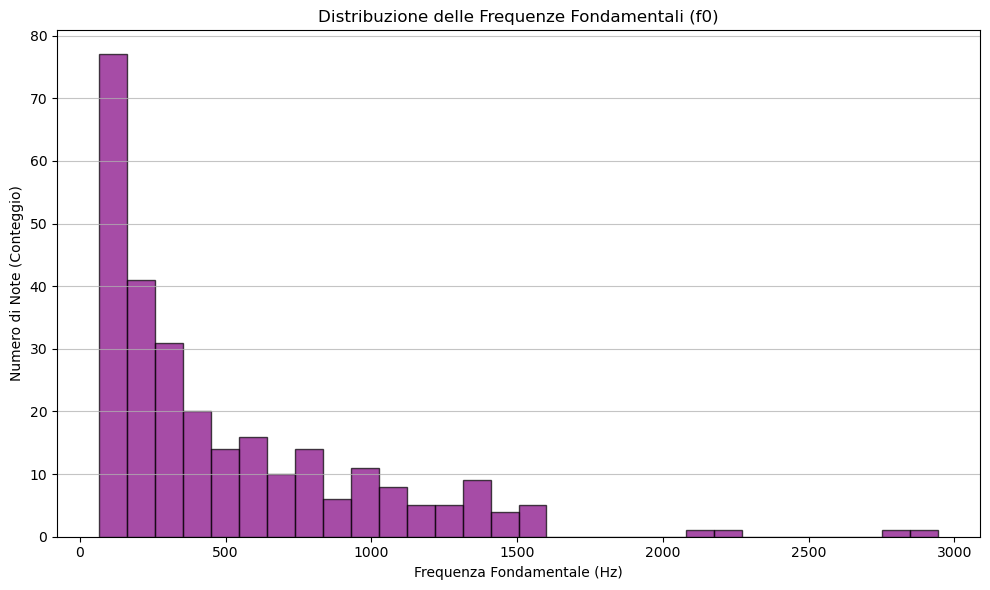

In [99]:
# Estrai tutte le frequenze fondamentali, ignorando eventuali valori a 0 (note non identificate)
f0_values = [data['f0'] for data in results.values() if data['f0'] > 0]

# Crea l'istogramma
plt.figure(figsize=(10, 6))
plt.hist(f0_values, bins=30, color='purple', edgecolor='black', alpha=0.7)

# Personalizza il grafico
plt.title('Distribuzione delle Frequenze Fondamentali (f0)')
plt.xlabel('Frequenza Fondamentale (Hz)')
plt.ylabel('Numero di Note (Conteggio)')
plt.grid(axis='y', alpha=0.75)

# Mostra il grafico
plt.tight_layout()
plt.show()

# sarebbe bello avere delle frequenze di riferimento per le note musicali e vedere se le frequenze fondamentali identificate si allineano con queste frequenze teoriche. 
# Potremmo anche colorare l'istogramma in base alla vicinanza alle frequenze di riferimento per evidenziare quali note sono più rappresentate.

# Estraiamo le ampiezze degli overtoni (armoniche)

In [100]:
def estrai_ampiezze_armoniche(freqs, psd, f0, num_armoniche):
    """Estrae l'ampiezza delle prime N armoniche e le normalizza."""
    armoniche = []
    
    for i in range(1, num_armoniche + 1):
        f_target = f0 * i
        # Trova l'indice dell'array delle frequenze più vicino al multiplo esatto
        idx = np.argmin(np.abs(freqs - f_target))
        armoniche.append(psd[idx])
        
    armoniche = np.array(armoniche)
    
    # NORMALIZZAZIONE FONDAMENTALE: 
    # Dividiamo tutto per l'ampiezza della prima armonica (la f0). 
    # Così confrontiamo il "timbro" (le proporzioni) e non il volume assoluto della registrazione!
    if armoniche[0] > 0:
        armoniche = armoniche / armoniche[0] 
        
    return armoniche

## K-means

In [101]:
# 1. Creiamo la matrice X delle features: ogni riga è una nota, 
# ogni colonna è l'ampiezza normalizzata(ridpetto all'ampiezza della sua f0) di un'armonica (es. 2a, 3a, 4a, 5a).
X = []
nomi_file = []

for file_name, data in results.items():
    if data['f0'] > 0: # Procediamo solo se la nota è stata identificata
        # Estraiamo le prime 5 armoniche
        features = estrai_ampiezze_armoniche(data['freq'], data['psd'], data['f0'], num_armoniche=5)
        
        # Ignoriamo la prima colonna (che ora vale sempre 1.0 per via della normalizzazione)
        # e usiamo le armoniche dalla 2 alla 5 come "coordinate" del nostro suono si possono usare anche più dimenssioni (tipo 10 armoniche)
        X.append(features[1:]) 
        nomi_file.append(file_name)

X = np.array(X)

# 2. Applichiamo il K-Means
# Scegli il numero di cluster (K). Se sai di avere 3 registri diversi nel dataset, metti 3.
NUMERO_REGISTRI = 5
kmeans = KMeans(n_clusters=NUMERO_REGISTRI, random_state=42)

# Addestriamo il modello e otteniamo le etichette (i gruppi assegnati)
labels = kmeans.fit_predict(X)

# 3. Stampiamo i risultati
print("\n--- RISULTATI CLUSTERING ---")
for name, label in zip(nomi_file, labels):
    print(f"File: {name} -> Assegnato al Cluster (Registro): {label}")


--- RISULTATI CLUSTERING ---
File: note_1.wav -> Assegnato al Cluster (Registro): 0
File: note_10.wav -> Assegnato al Cluster (Registro): 0
File: note_100.wav -> Assegnato al Cluster (Registro): 0
File: note_101.wav -> Assegnato al Cluster (Registro): 0
File: note_102.wav -> Assegnato al Cluster (Registro): 0
File: note_103.wav -> Assegnato al Cluster (Registro): 0
File: note_104.wav -> Assegnato al Cluster (Registro): 0
File: note_105.wav -> Assegnato al Cluster (Registro): 0
File: note_106.wav -> Assegnato al Cluster (Registro): 0
File: note_107.wav -> Assegnato al Cluster (Registro): 0
File: note_108.wav -> Assegnato al Cluster (Registro): 0
File: note_109.wav -> Assegnato al Cluster (Registro): 0
File: note_11.wav -> Assegnato al Cluster (Registro): 0
File: note_110.wav -> Assegnato al Cluster (Registro): 0
File: note_111.wav -> Assegnato al Cluster (Registro): 0
File: note_112.wav -> Assegnato al Cluster (Registro): 0
File: note_113.wav -> Assegnato al Cluster (Registro): 0
File:

In [ ]:
# Supponiamo che 'X' sia la tua matrice con 5 armoniche (f0, f1, f2, f3, f4)
# X = np.array(...) 

# 1. Standardizzazione (Fondamentale per la PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Applicazione della PCA per ridurre a 2 dimensioni
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Esecuzione del K-Means sui dati "schiacciati" dalla PCA
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_pca) # o su X_scaled, il risultato visivo sarà coerente

In [ ]:
plt.figure(figsize=(10, 7))

# Plot dei punti
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=60, alpha=0.8, edgecolors='k')

# Plot dei centroidi
centroids_pca = kmeans.cluster_centers_
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroidi')

# Calcolo della varianza spiegata (per capire quanto è accurato il riassunto)
var_exp = pca.explained_variance_ratio_
plt.title(f"Classificazione Registri via PCA (Varianza spiegata: {sum(var_exp)*100:.1f}%)")
plt.xlabel(f"Componente Principale 1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"Componente Principale 2 ({var_exp[1]*100:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
results_df = pd.DataFrame({'File': nomi_file, 'Cluster': labels})
for i in range(n_clusters):
    print(f"\nNote nel Cluster {i} (Probabile Registro {i}):")
    print(results_df[results_df['Cluster'] == i]['File'].values)